# Chebyshev Policies and the Mountain Car Problem: Reinforcement Learning for Low-dimensional Control Tasks
## ARS utilizing Chebyshev polynomial basis  

Can a more sophisticated Algorithm boost results?  
As ARS turned out as the best SOTA neural algorithm and it is targeted at linear policies, it is a natural choice.  
We implement Chebyshev approximators for use with the Stable Baselines3 framework to utilize its ARS implementation.  

Version 1.0   
Date: 2026-01-29   
Current version: hannes.unger@fh-salzburg.ac.at    

In [ ]:
import os
import time
import numpy as np
import multiprocessing as mp
import matplotlib.pyplot as plt
from utils import exp_run, plot

from pickleshare import PickleShareDB
db = PickleShareDB('./picklesharedb')

tensorboard_log_dir = "./tensorboard_logs/"
os.makedirs(tensorboard_log_dir, exist_ok=True)

%load_ext autoreload
%autoreload 2

## Training

In [2]:
# Hyperparameters adapted from https://huggingface.co/sb3/ars-MountainCarContinuous-v0
env_name = "MountainCarContinuous-v0"
tensorboard_dir = tensorboard_log_dir + "ars_mountaincarcontinuous"
delta_std = 0.1
n_delta = 4
n_top = 1
learning_rate = 0.018
n_timesteps = 80000
num_policies = 20
zero_policy = False
evaluate_every_n_steps = 10000
seed = 0
chebyshev_degree = 3
num_cores=mp.cpu_count()
name_prefix_chebyshev = 'mountaincar_ch-ars_'
name_prefix_mlp = 'mountaincar_mlp-ars_'

kwargs_ars = {'algo': 'ars', 'degree': 3, 'learning_rate': learning_rate, 'steps': n_timesteps, 'env_name': env_name, 'tensorboard_log_dir': tensorboard_dir, 
              'name': name_prefix_chebyshev, 'seed': seed, 'delta_std': delta_std, 'n_delta': n_delta, 'evaluate_every_n_steps': evaluate_every_n_steps, 'n_top': n_top}

In [ ]:
args, logdirs = plot.get_kwargs_with_distinct_seeds(kwargs=kwargs_ars, num_experiments=num_policies, name_prefix=name_prefix_chebyshev, seed=seed)

In [ ]:
start = time.time()
with mp.Pool(processes=num_cores) as pool:
    results = pool.map(exp_run.run_sb3_polyagent_training, args)

# Permanently store results
db['mountaincar_sb3_chebyshev_ars_20251105'] = results
print(f'Execution took {time.time()-start:.0f} seconds')

In [ ]:
# testing setting deterministic starting position with vec_env
chebyshev_results = db['mountaincar_sb3_chebyshev_ars_20251105']
model, eval_env = exp_run.get_sb3_polynomial_model_and_eval_env(basis='chebyshev', env_name=env_name, coeffs=chebyshev_results[0][-1], algo='ars')
start_loc=0.6
options={'low': start_loc, 'high': start_loc}
eval_env.venv.envs[0].reset(options=options)

## Evaluation

As for our plot in the paper comparing SOTA agents (see below), we sample 100 equidistand deterministic starting points over the interval [-0.4, -0.6], covering the entire initialization range. In the picture below, the best agent by mean reward is depicted in the context of the SOTA agent comparison of our paper.

In [ ]:
xs = np.linspace(-0.6, -0.4, 100)
chebyshev_results = db['mountaincar_sb3_chebyshev_ars_20251105']

chebyshev_eval_results = []

for c in chebyshev_results:
    rewards = []
    for x in xs:
        model, eval_env = exp_run.get_sb3_polynomial_model_and_eval_env(basis='chebyshev', env_name=env_name, coeffs=c[-1], algo='ars')
        rewards.append(exp_run.run_sb3_model(model, eval_env, options={'low': x, 'high': x})[0])
    chebyshev_eval_results.append([np.mean(rewards), np.std(rewards), np.min(rewards), np.max(rewards)])

db['mountaincar_chebyshev_ars_eval_results_20251105'] = chebyshev_eval_results

In [ ]:
chebyshev_eval_results

In [ ]:
chebyshev_training_results = db['mountaincar_sb3_chebyshev_ars_20251105']
chebyshev_eval_results = db['mountaincar_chebyshev_ars_eval_results_20251105']
plot.print_eval_results([chebyshev_eval_results], [chebyshev_training_results], env_name=env_name)


MountainCarContinuous-v0: Top evaluation results after training
Rank   Model Name                Reward    
------ ------------------------- ----------
1      mountaincar_ch-ars__20251106_0946_17_237349 98.9503    0       
2      mountaincar_ch-ars__20251106_0948_17_521527 98.8624    0       
3      mountaincar_ch-ars__20251106_0946_17_516748 98.7457    0       
4      mountaincar_ch-ars__20251106_0946_16_111891 98.6733    0       
5      mountaincar_ch-ars__20251106_0948_8_061488 98.6386    0       

      MountainCarContinuous-v0: Top group results after training      

Group 0
-------
Rank   Model Name                     Reward    
       ------------------------------ ----------
1      mountaincar_ch-ars__20251106_0946_17_237349 98.9503   
2      mountaincar_ch-ars__20251106_0948_17_521527 98.8624   
3      mountaincar_ch-ars__20251106_0946_17_516748 98.7457   



In [3]:
chebyshev_training_results = db['mountaincar_sb3_chebyshev_ars_20251105']
best_agent_name = 'mountaincar_ch-ars__20251106_0946_17_237349'
best_agent = next(((i, row) for i, row in enumerate(chebyshev_training_results) if row[0] == best_agent_name), None)
best_agent_coeffs = best_agent[-1][-1]
best_agent_index = best_agent[0]
db['mountaincar_ch_ars_best_agent_params'] = best_agent_coeffs

How does this CH-ARS policy look like? Interestingly, not as clean as expected.  
Locations in the state-space that can be expected to be visited frequently seem good in the ars result, while elsewhere the policy looks suboptimal.  
However, action magnitude especially around the center seems lower compared to REINFORCE.  
It seems that the algorithm effectively optimizes regions that are actually visited by successful trajectories.  

Using cpu device


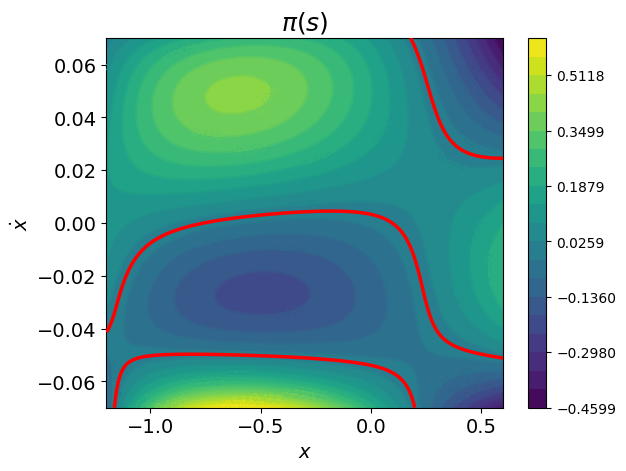

In [243]:
model, eval_env = exp_run.get_sb3_polynomial_model_and_eval_env(basis='chebyshev', env_name=env_name, coeffs=best_agent_coeffs, algo='ars')

plot.plot_sb3_chebyshev_mountaincar_policy(model, algo='ars')

In [265]:
chebyshev_eval_results[best_agent_index]

[np.float32(98.95029),
 np.float32(0.09871318),
 np.float32(98.74157),
 np.float32(99.10945)]

Text(0.5, 1.2, 'Min, mean and max reward, episode length and velocity at target for different trained agents\nLeft wall at $x=-1.2$, $100$ evenly spaced starting positions over the interval $x_0 \\in [-0.6, -0.4]$\n$C_1=$4.3346, $C_2=$4.8358')

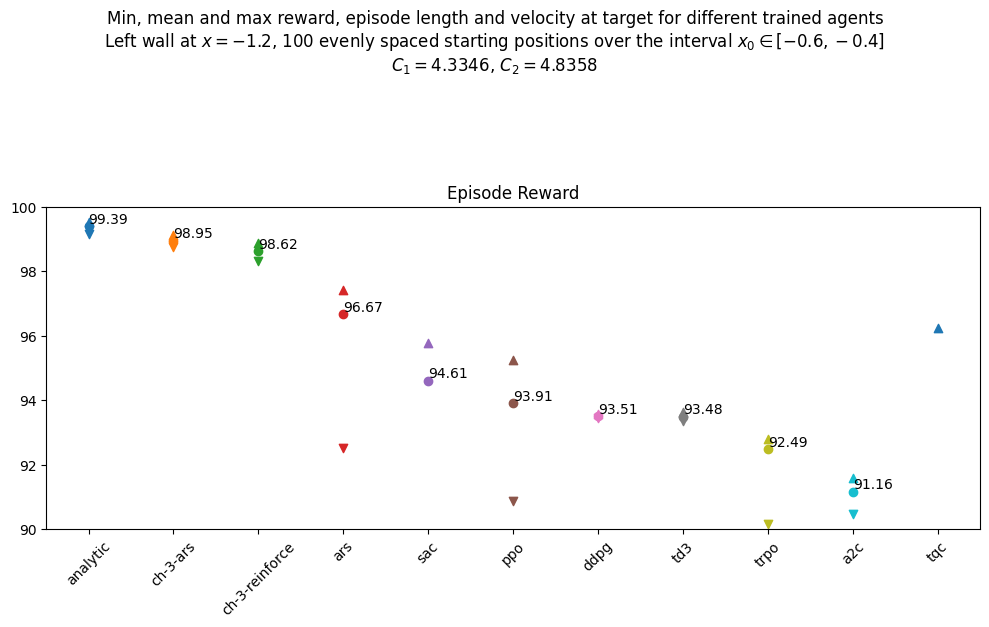

In [275]:
import matplotlib.gridspec as gridspec

results = db['huggingface_single_episode_results']
results_analytic = db['analytic_single_episode_results']
results_chebyshev3= db['chebyshev_single_episode_results'] 
results_chebyshev_ars = db['mountaincar_chebyshev_ars_eval_results_20251105']
r_analytic = [a[1] for a in results_analytic]
target_velocities_analytic = [a[3] for a in results_analytic]
steps_analytic = [len(a[4]) for a in results_analytic]

r_chebyshev3 = [a[0] for a in results_chebyshev3]
target_velocities_chebyshev3 = [a[2][-1][1] for a in results_chebyshev3]
steps_chebyshev3 = [len(a[2]) for a in results_chebyshev3]

chebyshev_ars_episode_reward = [results_chebyshev_ars[best_agent_index][2], results_chebyshev_ars[best_agent_index][0], results_chebyshev_ars[best_agent_index][-1]]
chebyshev3_episode_reward = [np.min([r for r in r_chebyshev3]), np.mean([r for r in r_chebyshev3]), np.max([r for r in r_chebyshev3])]
analytic_episode_reward = [np.min([r for r in r_analytic]), np.mean([r for r in r_analytic]), np.max([r for r in r_analytic])]
ars_episode_reward = [np.min([r[0] for r in results[7]]), np.mean([r[0] for r in results[7]]), np.max([r[0] for r in results[7]])]
ddpg_episode_reward = [np.min([r[0] for r in results[6]]), np.mean([r[0] for r in results[6]]), np.max([r[0] for r in results[6]])]
a2c_episode_reward = [np.min([r[0] for r in results[5]]), np.mean([r[0] for r in results[5]]), np.max([r[0] for r in results[5]])]
trpo_episode_reward = [np.min([r[0] for r in results[4]]), np.mean([r[0] for r in results[4]]), np.max([r[0] for r in results[4]])]
td3_episode_reward = [np.min([r[0] for r in results[3]]), np.mean([r[0] for r in results[3]]), np.max([r[0] for r in results[3]])]
sac_episode_reward = [np.min([r[0] for r in results[2]]), np.mean([r[0] for r in results[2]]), np.max([r[0] for r in results[2]])]
tqc_episode_reward = [np.min([r[0] for r in results[1]]), np.mean([r[0] for r in results[1]]), np.max([r[0] for r in results[1]])]
ppo_episode_reward = [np.min([r[0] for r in results[0]]), np.mean([r[0] for r in results[0]]), np.max([r[0] for r in results[0]])]

data = {'ars': ars_episode_reward, 'ddpg': ddpg_episode_reward, 'a2c': a2c_episode_reward, 'trpo': trpo_episode_reward, 'td3': td3_episode_reward, 'sac': sac_episode_reward, 'tqc': tqc_episode_reward, 'ppo': ppo_episode_reward, 'analytic': analytic_episode_reward, 'ch-3-reinforce': chebyshev3_episode_reward, 'ch-3-ars': chebyshev_ars_episode_reward}
sorted_data = dict(sorted(data.items(), key=lambda item: item[1][1], reverse=True)) # sort by mean reward

fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0, :])  # Span all columns

# Plt1: Extract names and values
names = list(sorted_data.keys())
values = list(sorted_data.values())

# Create a consistent color mapping for names
unique_names = list(sorted_data.keys())  # Start with names from data1
colors = [plt.cm.tab10(i % 10) for i in range(len(unique_names))]
color_map = {name: colors[i] for i, name in enumerate(unique_names)}

# # Include new names from the second dictionary and assign new colors if needed
# for name in len_data.keys():
#     if name not in color_map:
#         color_map[name] = plt.cm.tab10(len(color_map) % 10)  # Cycle through colors

for i, (name, value) in enumerate(sorted_data.items()):
    ax1.scatter(i, value[0], color=color_map[name], label=name, marker='v')
    ax1.scatter(i, value[1], color=color_map[name], label=name, marker='o')
    ax1.scatter(i, value[2], color=color_map[name], label=name, marker='^')
    # Add the value next to the point
    if value[1] > 90:
        #ax1.text(i, value[0], f"{value[0]:.2f}", fontsize=10, verticalalignment='bottom')
        ax1.text(i, value[1], f"{value[1]:.2f}", fontsize=10, verticalalignment='bottom')
        #ax1.text(i, value[2], f"{value[2]:.2f}", fontsize=10, verticalalignment='bottom')

ax1.set_xticks(range(len(names)), names, fontsize=10, rotation=45)
ax1.set_title("Episode Reward")
ax1.set_ylim([90,100])



fig.tight_layout()  # otherwise the right y-label is slightly clipped
fig.suptitle(r'Min, mean and max reward, episode length and velocity at target for different trained agents' '\n' r'Left wall at $x=-1.2$, $100$ evenly spaced starting positions over the interval $x_0 \in [-0.6, -0.4]$' '\n'  r'$C_1=$' f'{db["c1_max_1000"]:.4f}, ' r'$C_2=$' f'{db["c2_optimum"]:.4f}', y=1.2)

CH-ARS  beats CH-REINFORCE by a small margin. Also variance in reward across the observed initialization range is lower.